In [1]:
print("hello")

hello


In [2]:
import yfinance as yf
import pandas as pd

df = yf.download("AAPL", period="6mo", interval="1d")

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df.reset_index()
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
0,2025-09-22,255.592819,256.151782,247.647971,247.827636,105517400
1,2025-09-23,253.945969,256.850436,253.097595,255.393222,60275200
2,2025-09-24,251.830002,255.253485,250.562414,254.734469,42303700
3,2025-09-25,256.381317,256.680765,251.231145,252.728292,55202100
4,2025-09-26,254.974014,257.109942,253.297202,253.616601,46076300


In [3]:
df.to_csv("data/aapl_data_clean.csv", index=False)
print("saved")

OSError: Cannot save file into a non-existent directory: 'data'

In [4]:
df.to_csv("../data/aapl_data_clean.csv", index=False)
print("saved")

saved


In [5]:
df.shape

(125, 6)

In [6]:
df.describe

<bound method NDFrame.describe of Price       Date       Close        High         Low        Open     Volume
0     2025-09-22  255.592819  256.151782  247.647971  247.827636  105517400
1     2025-09-23  253.945969  256.850436  253.097595  255.393222   60275200
2     2025-09-24  251.830002  255.253485  250.562414  254.734469   42303700
3     2025-09-25  256.381317  256.680765  251.231145  252.728292   55202100
4     2025-09-26  254.974014  257.109942  253.297202  253.616601   46076300
..           ...         ...         ...         ...         ...        ...
120   2026-03-16  252.820007  253.889999  249.880005  252.110001   32074200
121   2026-03-17  254.229996  255.130005  252.179993  252.960007   32361600
122   2026-03-18  249.940002  254.940002  249.000000  252.630005   35757900
123   2026-03-19  248.960007  251.830002  247.300003  249.399994   34864100
124   2026-03-20  247.990005  249.199905  246.000000  248.110001   87981315

[125 rows x 6 columns]>

In [7]:
df.describe()

Price,Date,Close,High,Low,Open,Volume
count,125,125.000000,125.000000,125.000000,125.000000,1.250000e+02
mean,2025-12-19 20:44:09,264.400514,267.023571,261.872913,264.435703,4.737731e+07
min,2025-09-22 00:00:00,244.803406,248.376592,243.192443,246.130873,1.791060e+07
25%,2025-11-04 00:00:00,256.381317,258.657967,254.272083,256.321455,3.770430e+07
50%,2025-12-18 00:00:00,264.350006,267.299866,261.420013,263.600006,4.466410e+07
75%,2026-02-04 00:00:00,272.694855,275.172509,270.646752,272.554970,5.045340e+07
max,2026-03-20 00:00:00,285.922455,288.350192,283.035157,285.932471,1.446320e+08
std,NaN,9.780740,9.791026,9.879871,9.778939,1.774126e+07


<Axes: xlabel='Date'>

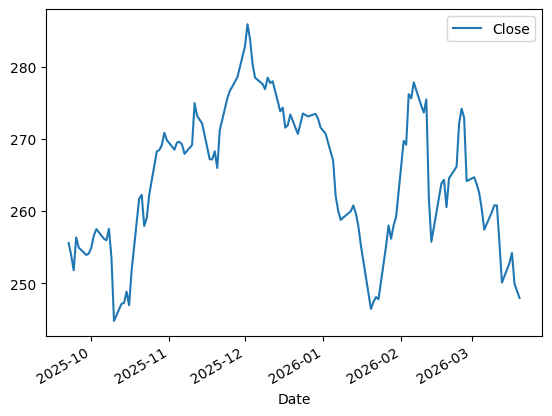

In [8]:
df.plot(x="Date", y="Close")

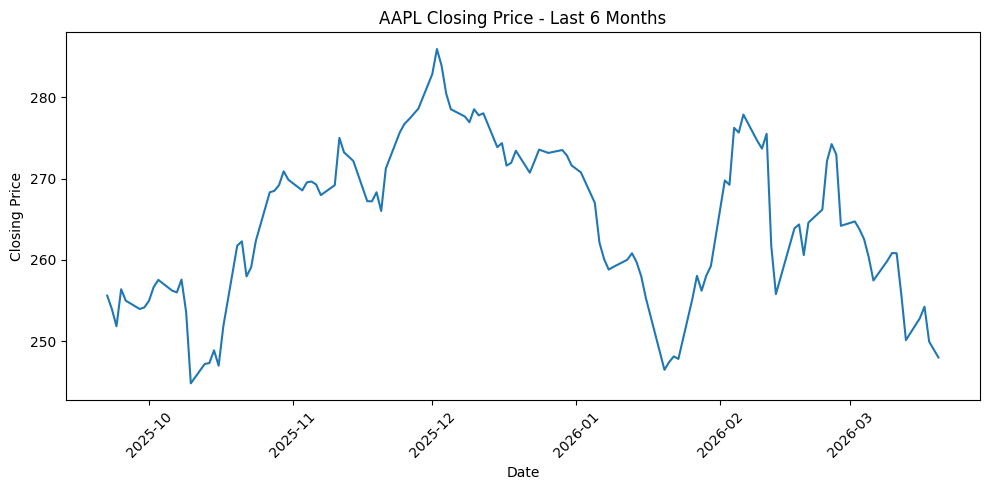

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["Close"])
plt.title("AAPL Closing Price Last 6 Months")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


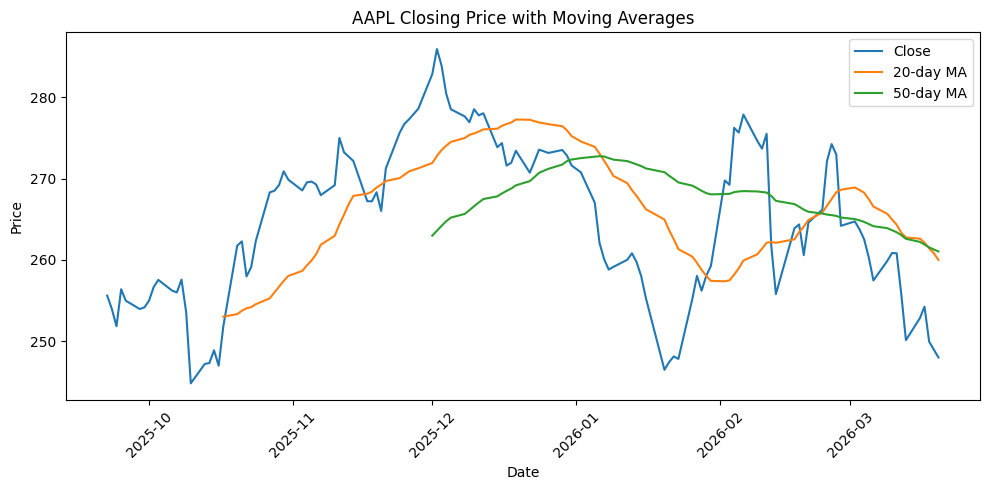

In [10]:
import matplotlib.pyplot as plt

df["MA20"] = df["Close"].rolling(20).mean()
df["MA50"] = df["Close"].rolling(50).mean()

plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["MA20"], label="20-day MA")
plt.plot(df["Date"], df["MA50"], label="50-day MA")
plt.title("AAPL Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
df[["Date", "Close", "MA20", "MA50"]].tail()

Price,Date,Close,MA20,MA50
120,2026-03-16,252.820007,262.601499,262.204839
121,2026-03-17,254.229996,262.118999,261.874306
122,2026-03-18,249.940002,261.398499,261.532903
123,2026-03-19,248.960007,260.817500,261.269809
124,2026-03-20,247.990005,259.988000,261.027877


In [12]:
df["Signal"] = 0
df.loc[df["MA20"] > df["MA50"], "Signal"] = 1
df.loc[df["MA20"] <= df["MA50"], "Signal"] = -1

df[["Date", "Close", "MA20", "MA50", "Signal"]].tail(10)

Price,Date,Close,MA20,MA50,Signal
115,2026-03-09,259.880005,265.650000,263.890701,1
116,2026-03-10,260.829987,264.960500,263.636220,1
117,2026-03-11,260.809998,264.317000,263.389532,1
118,2026-03-12,255.759995,263.330000,263.034650,1
119,2026-03-13,250.119995,262.749499,262.580556,1
120,2026-03-16,252.820007,262.601499,262.204839,1
121,2026-03-17,254.229996,262.118999,261.874306,1
122,2026-03-18,249.940002,261.398499,261.532903,-1
123,2026-03-19,248.960007,260.817500,261.269809,-1
124,2026-03-20,247.990005,259.988000,261.027877,-1


In [13]:
df["Regime"] = "Bearish"
df.loc[df["Signal"] == 1, "Regime"] = "Bullish"

df[["Date", "Close", "MA20", "MA50", "Signal", "Regime"]].tail(10)

Price,Date,Close,MA20,MA50,Signal,Regime
115,2026-03-09,259.880005,265.650000,263.890701,1,Bullish
116,2026-03-10,260.829987,264.960500,263.636220,1,Bullish
117,2026-03-11,260.809998,264.317000,263.389532,1,Bullish
118,2026-03-12,255.759995,263.330000,263.034650,1,Bullish
119,2026-03-13,250.119995,262.749499,262.580556,1,Bullish
120,2026-03-16,252.820007,262.601499,262.204839,1,Bullish
121,2026-03-17,254.229996,262.118999,261.874306,1,Bullish
122,2026-03-18,249.940002,261.398499,261.532903,-1,Bearish
123,2026-03-19,248.960007,260.817500,261.269809,-1,Bearish
124,2026-03-20,247.990005,259.988000,261.027877,-1,Bearish


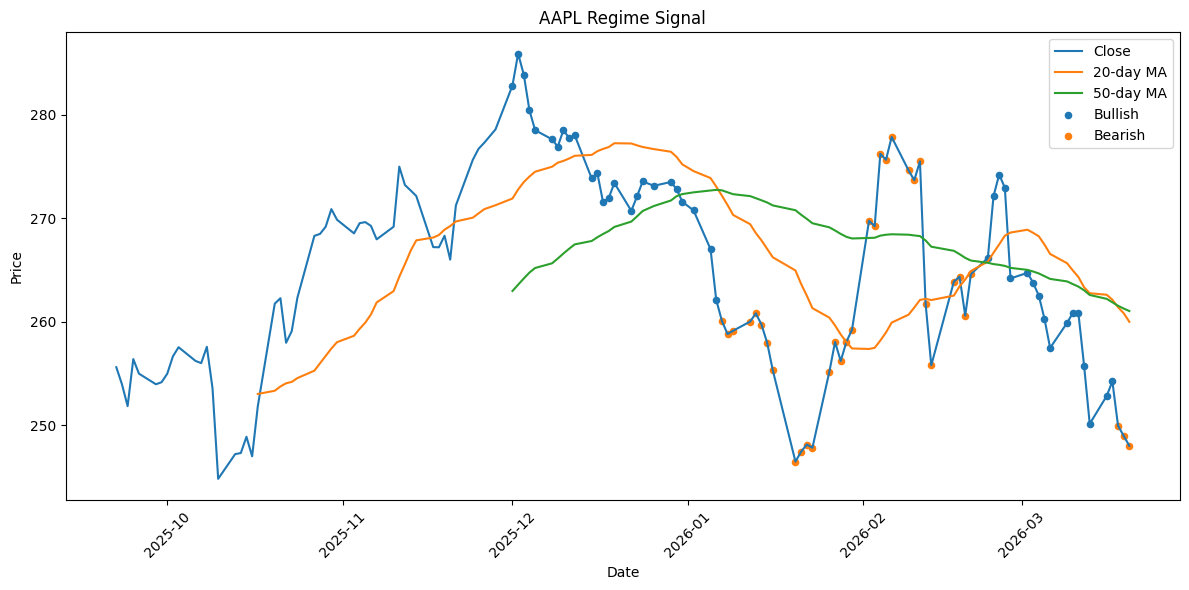

In [14]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["MA20"], label="20-day MA")
plt.plot(df["Date"], df["MA50"], label="50-day MA")

bullish = df[df["Signal"] == 1]
bearish = df[df["Signal"] == -1]

plt.scatter(bullish["Date"], bullish["Close"], label="Bullish", s=20)
plt.scatter(bearish["Date"], bearish["Close"], label="Bearish", s=20)

plt.title("AAPL Regime Signal")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

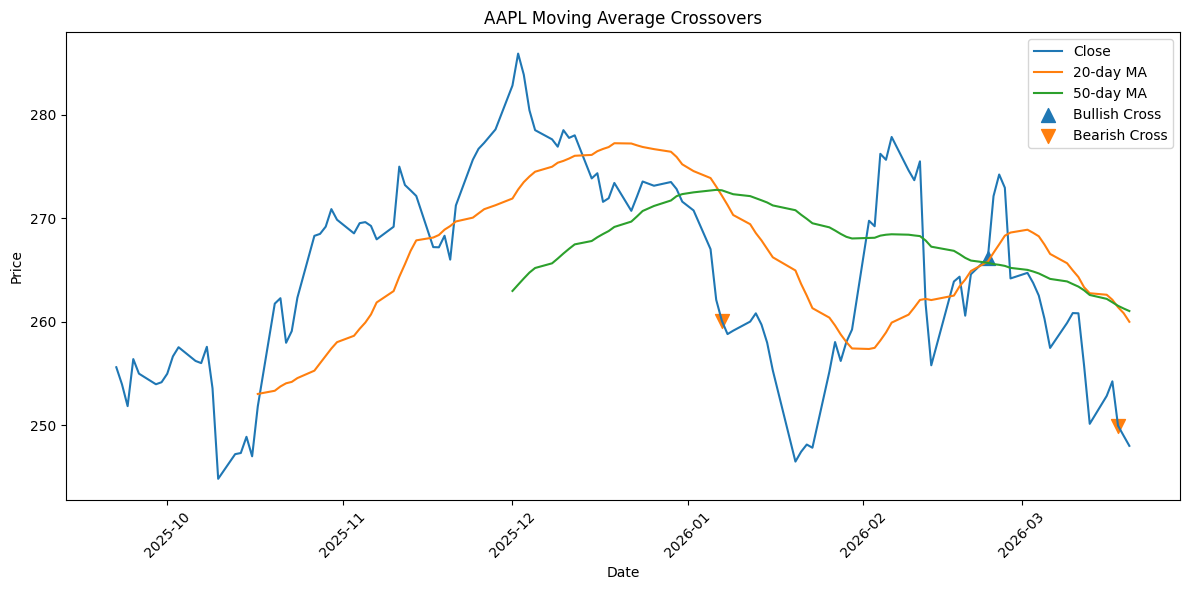

In [15]:
df["Crossover"] = df["Signal"].diff()

cross_up = df[df["Crossover"] == 2]
cross_down = df[df["Crossover"] == -2]

plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["MA20"], label="20-day MA")
plt.plot(df["Date"], df["MA50"], label="50-day MA")

plt.scatter(cross_up["Date"], cross_up["Close"], marker="^", s=100, label="Bullish Cross")
plt.scatter(cross_down["Date"], cross_down["Close"], marker="v", s=100, label="Bearish Cross")

plt.title("AAPL Moving Average Crossovers")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
df.to_csv("../data/aapl_regime_signals.csv", index=False)
print("saved regime file")

saved regime file


In [1]:
spy = yf.download("SPY", period="6mo", interval="1d")

if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.get_level_values(0)

spy = spy.reset_index()
spy.head()

NameError: name 'yf' is not defined

In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
spy = yf.download("SPY", period="6mo", interval="1d")

if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.get_level_values(0)

spy = spy.reset_index()
spy.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
0,2025-09-22,663.064514,663.511918,658.420911,658.450770,69452200
1,2025-09-23,659.455139,663.561761,658.232062,662.945216,81708900
2,2025-09-24,657.356995,660.847132,655.935098,660.747722,68082200
3,2025-09-25,654.324280,655.676565,650.704874,654.214917,89622100
4,2025-09-26,658.072998,658.619872,654.155303,655.776079,69179200


In [2]:
df = yf.download("AAPL", period="6mo", interval="1d")

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df.reset_index()
df.head()

NameError: name 'yf' is not defined

In [5]:
aapl_compare = df[["Date", "Close"]].copy()
aapl_compare = aapl_compare.rename(columns={"Close": "AAPL_Close"})

spy_compare = spy[["Date", "Close"]].copy()
spy_compare = spy_compare.rename(columns={"Close": "SPY_Close"})

compare = pd.merge(aapl_compare, spy_compare, on="Date", how="inner")

compare["AAPL_Index"] = compare["AAPL_Close"] / compare["AAPL_Close"].iloc[0] * 100
compare["SPY_Index"] = compare["SPY_Close"] / compare["SPY_Close"].iloc[0] * 100

compare.head()

NameError: name 'df' is not defined

In [7]:
aapl_compare = df[["Date", "Close"]].copy()
aapl_compare = aapl_compare.rename(columns={"Close": "AAPL_Close"})

spy_compare = spy[["Date", "Close"]].copy()
spy_compare = spy_compare.rename(columns={"Close": "SPY_Close"})

compare = pd.merge(aapl_compare, spy_compare, on="Date", how="inner")

compare["AAPL_Index"] = compare["AAPL_Close"] / compare["AAPL_Close"].iloc[0] * 100
compare["SPY_Index"] = compare["SPY_Close"] / compare["SPY_Close"].iloc[0] * 100

compare.head()

Price,Date,AAPL_Close,SPY_Close,AAPL_Index,SPY_Index
0,2025-09-22,255.592819,663.064514,100.000000,100.000000
1,2025-09-23,253.945969,659.455139,99.355674,99.455653
2,2025-09-24,251.830002,657.356995,98.527808,99.139221
3,2025-09-25,256.381317,654.324280,100.308498,98.681843
4,2025-09-26,254.974014,658.072998,99.757894,99.247205


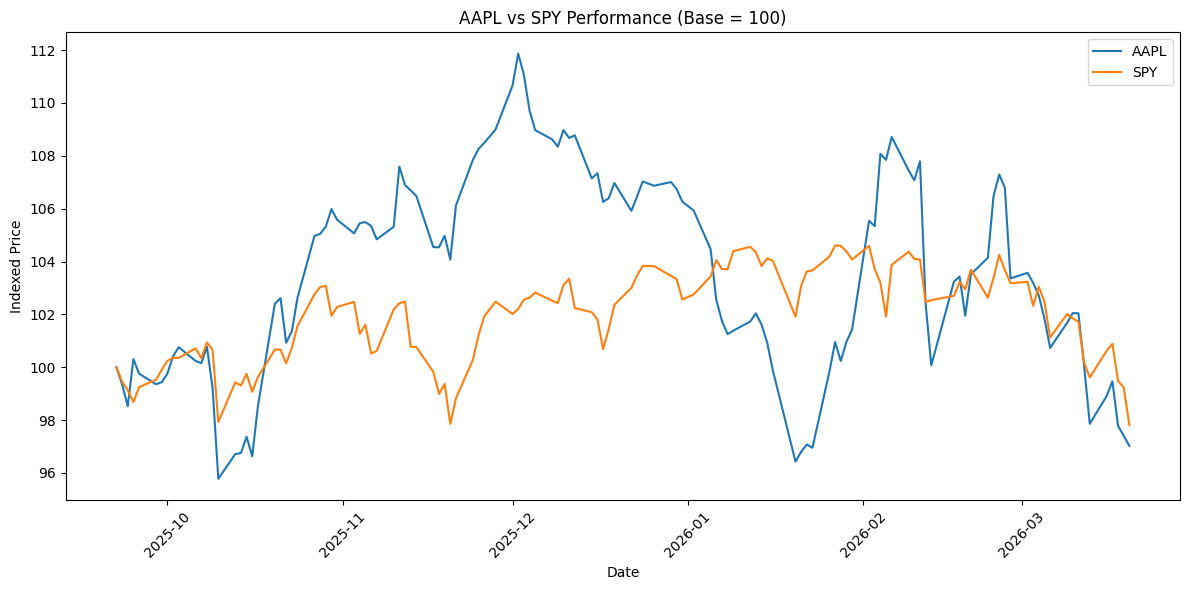

In [8]:
plt.figure(figsize=(12,6))
plt.plot(compare["Date"], compare["AAPL_Index"], label="AAPL")
plt.plot(compare["Date"], compare["SPY_Index"], label="SPY")
plt.title("AAPL vs SPY Performance (Base = 100)")
plt.xlabel("Date")
plt.ylabel("Indexed Price")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
compare["AAPL_Return"] = compare["AAPL_Close"].pct_change()
compare["SPY_Return"] = compare["SPY_Close"].pct_change()

compare[["Date", "AAPL_Return", "SPY_Return"]].head()

Price,Date,AAPL_Return,SPY_Return
0,2025-09-22,NaN,NaN
1,2025-09-23,-0.006443,-0.005443
2,2025-09-24,-0.008332,-0.003182
3,2025-09-25,0.018073,-0.004613
4,2025-09-26,-0.005489,0.005729


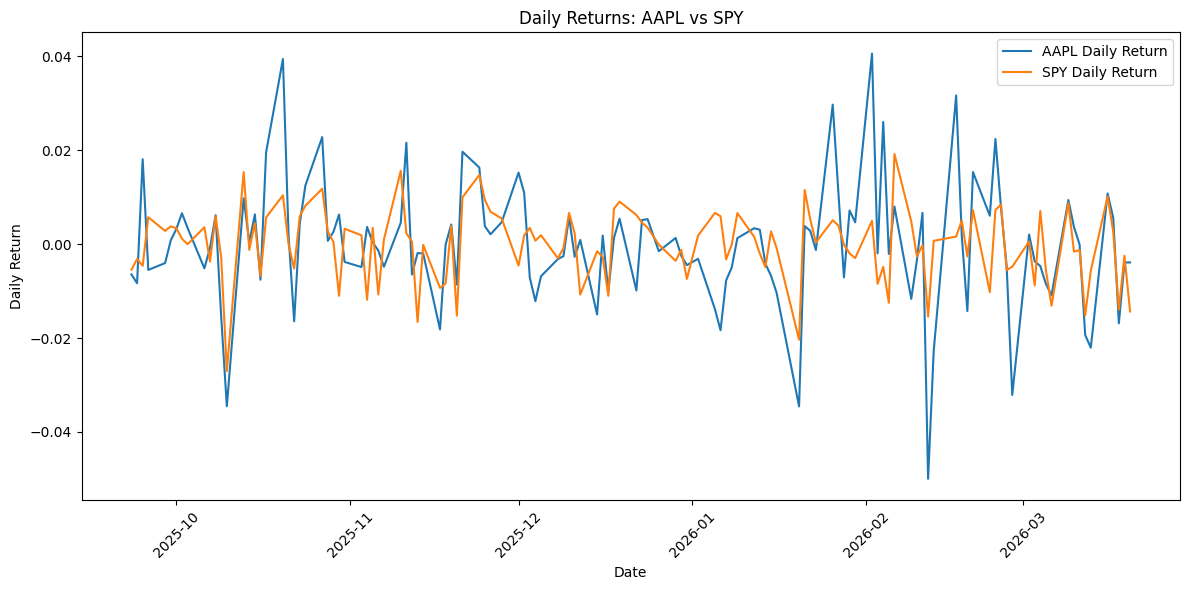

In [10]:
plt.figure(figsize=(12,6))
plt.plot(compare["Date"], compare["AAPL_Return"], label="AAPL Daily Return")
plt.plot(compare["Date"], compare["SPY_Return"], label="SPY Daily Return")
plt.title("Daily Returns: AAPL vs SPY")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
compare[["AAPL_Return", "SPY_Return"]].std()

Price
AAPL_Return    0.013264
SPY_Return     0.007739
dtype: float64

compare[["AAPL_Return", "SPY_Return"]].mean()

## Key Findings

- AAPL was more volatile than SPY over the last 6 months.
- The standard deviation of AAPL daily returns was about 1.33%, compared with 0.77% for SPY.
- Both AAPL and SPY had slightly negative average daily returns over this sample period.
- Moving-average crossover signals identified bullish and bearish regime changes in AAPL.
- Relative performance analysis showed that AAPL was more volatile and finished weaker than SPY by the end of the sample.

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [1]:
delta = df["Close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss
df["RSI14"] = 100 - (100 / (1 + rs))

df[["Date", "Close", "RSI14"]].tail(10)

NameError: name 'df' is not defined

In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = yf.download("AAPL", period="6mo", interval="1d")

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df.reset_index()
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
0,2025-09-22,255.592819,256.151782,247.647971,247.827636,105517400
1,2025-09-23,253.945969,256.850436,253.097595,255.393222,60275200
2,2025-09-24,251.830002,255.253485,250.562414,254.734469,42303700
3,2025-09-25,256.381317,256.680765,251.231145,252.728292,55202100
4,2025-09-26,254.974014,257.109942,253.297202,253.616601,46076300


In [5]:
delta = df["Close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss
df["RSI14"] = 100 - (100 / (1 + rs))

df[["Date", "Close", "RSI14"]].tail(10)

Price,Date,Close,RSI14
115,2026-03-09,259.880005,44.758923
116,2026-03-10,260.829987,45.445118
117,2026-03-11,260.809998,50.329623
118,2026-03-12,255.759995,37.729577
119,2026-03-13,250.119995,29.914981
120,2026-03-16,252.820007,23.692823
121,2026-03-17,254.229996,22.253049
122,2026-03-18,249.940002,20.537773
123,2026-03-19,248.960007,25.655808
124,2026-03-20,247.990005,23.603657


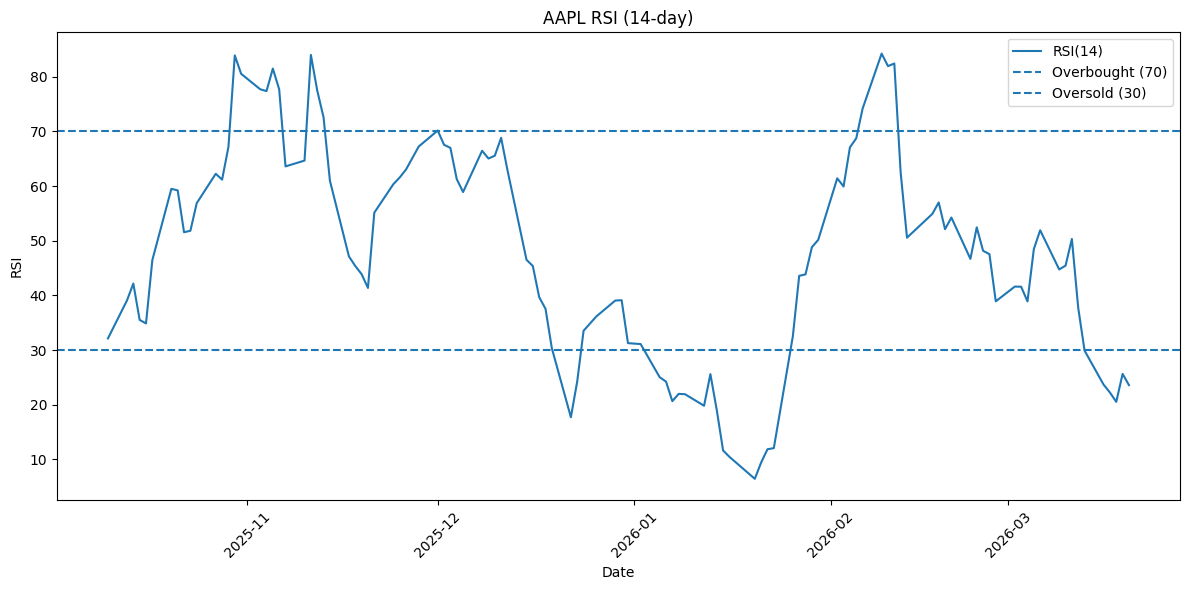

In [6]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["RSI14"], label="RSI(14)")
plt.axhline(70, linestyle="--", label="Overbought (70)")
plt.axhline(30, linestyle="--", label="Oversold (30)")
plt.title("AAPL RSI (14-day)")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## RSI Interpretation

- RSI above 70 suggests overbought conditions.
- RSI below 30 suggests oversold conditions.
- In this sample, AAPL moved through both overbought and oversold periods, showing strong momentum swings and high volatility.